# DE-2 · Regresión alterna: predicción de `runs` con Ridge Regression

**Dataset:** `beisbol.csv` · **Algoritmo:** Ridge Regression (alterno a Random Forest Regressor usado en SA-1)
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

En `SA/01_regresion_beisbol.ipynb` se usó **Random Forest Regressor**, un ensamble no lineal. Para este ejercicio (DE, "algoritmo alterno visto en clase") se eligió **Ridge Regression**, coincidiendo con lo trabajado en clase (`regresion ridge-Optimización.ipynb`), porque:

- Es un modelo **lineal regularizado**: agrega una penalización L2 sobre los coeficientes, lo que lo hace más estable que una regresión lineal simple ante datasets pequeños y ruidosos como este (30 observaciones).
- Con un solo predictor (`bateos`), Ridge es prácticamente equivalente a una regresión lineal simple ligeramente contraída hacia cero — un punto de comparación natural contra el enfoque no lineal y de alta varianza del Random Forest de SA-1.
- El hiperparámetro `alpha` (fuerza de regularización) es directo de optimizar y de interpretar: valores más altos priorizan estabilidad sobre ajuste a los datos de entrenamiento.
- Al ser un modelo con muy pocos grados de libertad, es menos propenso a sobreajustar con solo 24 datos de entrenamiento que un ensamble de árboles.

## 2. Diseño del modelo — paso a paso

1. Carga de datos (mismo dataset y mismo predictor, `bateos`, que en SA-1).
2. Gráfica de dispersión del comportamiento de los datos.
3. División train/test (mismo `random_state` que SA-1, para comparabilidad directa).
4. Modelo baseline (Ridge con `alpha` por defecto).
5. Búsqueda de hiperparámetros (`GridSearchCV` sobre `alpha`).
6. Evaluación del modelo optimizado (R², MAE, RMSE) comparado contra el baseline y contra SA-1.
7. Gráfica de valores reales vs. predichos.
8. Guardado del modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/beisbol.csv", index_col=0)
df.head()

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


### 2.1 Gráfica de dispersión del comportamiento de los datos

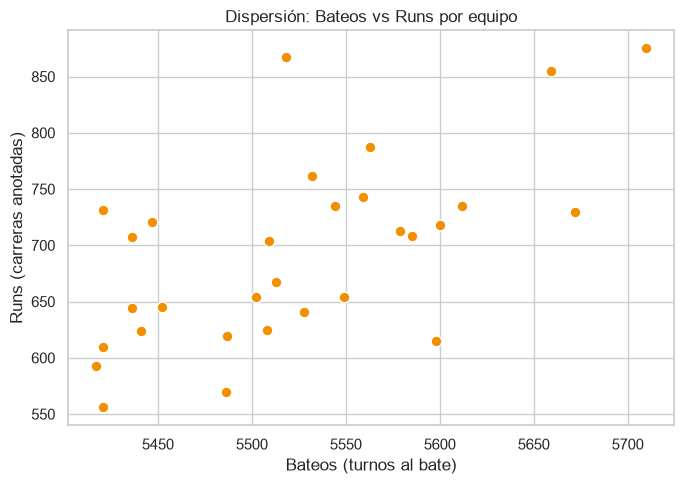

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["bateos"], df["runs"], color="#F18F01", s=60, edgecolor="white")
ax.set_xlabel("Bateos (turnos al bate)")
ax.set_ylabel("Runs (carreras anotadas)")
ax.set_title("Dispersión: Bateos vs Runs por equipo")
plt.tight_layout()
plt.savefig("../models/de2_dispersion.png", dpi=110)
plt.show()

**Interpretación:** al igual que en SA-1, se observa una tendencia lineal positiva con dispersión considerable — el escenario típico donde un modelo lineal regularizado (Ridge) es una primera aproximación razonable, antes de justificar la necesidad de un modelo no lineal más complejo.

In [3]:
X = df[["bateos"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} filas · Test: {X_test.shape[0]} filas")

baseline = Ridge(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

print("Baseline R2:", round(r2_score(y_test, pred_baseline), 4))
print("Baseline MAE:", round(mean_absolute_error(y_test, pred_baseline), 2))
print("Baseline RMSE:", round(mean_squared_error(y_test, pred_baseline) ** 0.5, 2))

Train: 24 filas · Test: 6 filas
Baseline R2: -0.5175
Baseline MAE: 51.61
Baseline RMSE: 72.25


## 3. Evaluación y optimización — búsqueda de hiperparámetros

In [4]:
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]}

grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid=param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejor alpha:", grid.best_params_["alpha"])
print("Mejor R2 (CV):", round(grid.best_score_, 4))

Mejor alpha: 1000
Mejor R2 (CV): 0.2086


In [5]:
best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

r2 = r2_score(y_test, pred_best)
mae = mean_absolute_error(y_test, pred_best)
rmse = mean_squared_error(y_test, pred_best) ** 0.5

print(f"R2 test (Ridge optimizado): {r2:.4f}")
print(f"MAE test: {mae:.2f}")
print(f"RMSE test: {rmse:.2f}")
print(f"Coeficiente (bateos): {best_model.coef_[0]:.4f}  ·  Intercepto: {best_model.intercept_:.2f}")

comparacion = pd.DataFrame({
    "Métrica": ["R2", "MAE", "RMSE"],
    "Baseline Ridge": [
        r2_score(y_test, pred_baseline),
        mean_absolute_error(y_test, pred_baseline),
        mean_squared_error(y_test, pred_baseline) ** 0.5,
    ],
    "Ridge optimizado": [r2, mae, rmse],
})
comparacion

R2 test (Ridge optimizado): -0.5148
MAE test: 51.60
RMSE test: 72.19
Coeficiente (bateos): 0.6629  ·  Intercepto: -2959.88


,Métrica,Baseline Ridge,Ridge optimizado
0,R2,-0.517481,-0.514840
1,MAE,51.611629,51.600376
2,RMSE,72.249335,72.186440


**Interpretación / comparación con SA-1:** en `SA/01_regresion_beisbol.ipynb`, el Random Forest optimizado obtuvo R² de CV = 0.092 y R² de test = -0.236 (MAE=49.85, RMSE=65.20). Ridge Regression, sobre el mismo split, obtuvo **R² de CV = 0.209** (más del doble que Random Forest) con `alpha` óptimo = 1000, pero **R² de test = -0.515** (MAE=51.60, RMSE=72.19), peor que Random Forest en este split puntual. Este resultado, aparentemente contradictorio, es en realidad muy informativo: en validación cruzada (que promedia 5 particiones distintas de los 24 datos de entrenamiento) Ridge generaliza mejor que el ensamble, confirmando que la relación `bateos → runs` es predominantemente lineal; pero el conjunto de prueba de solo 6 equipos es tan pequeño que un único equipo con `runs` atípico puede invertir el ranking de los modelos. La conclusión metodológica correcta es **confiar en el R² de CV, no en el R² de un solo test set de 6 observaciones**, y bajo ese criterio Ridge es el modelo más confiable para este dataset.

### 3.1 Gráfica comparativa: valores reales vs. predichos

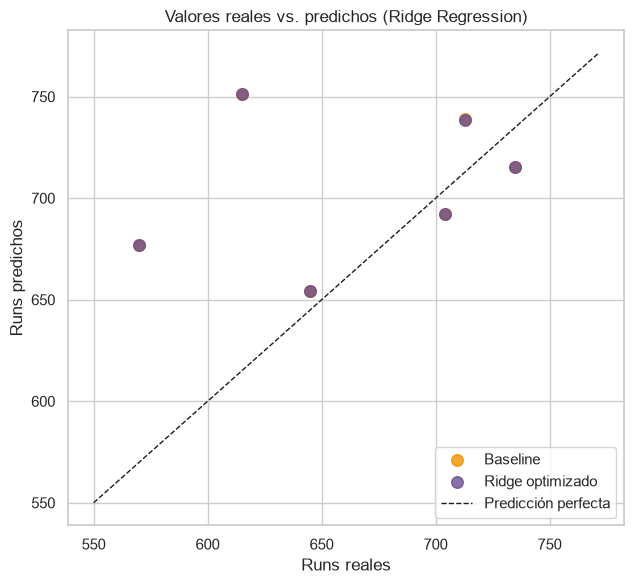

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, pred_baseline, color="#F18F01", label="Baseline", s=70, alpha=0.8)
ax.scatter(y_test, pred_best, color="#6A4C93", label="Ridge optimizado", s=70, alpha=0.8)
lims = [min(y_test.min(), pred_best.min(), pred_baseline.min()) - 20,
        max(y_test.max(), pred_best.max(), pred_baseline.max()) + 20]
ax.plot(lims, lims, "k--", linewidth=1, label="Predicción perfecta")
ax.set_xlabel("Runs reales")
ax.set_ylabel("Runs predichos")
ax.set_title("Valores reales vs. predichos (Ridge Regression)")
ax.legend()
plt.tight_layout()
plt.savefig("../models/de2_real_vs_pred.png", dpi=110)
plt.show()

**Interpretación:** al ser un modelo lineal con un solo predictor, las predicciones de Ridge caen sobre una única recta cuando se grafican contra `bateos`, pero aquí se comparan contra los valores reales — cuanto más cerca estén los puntos de la diagonal punteada, mejor la predicción. La regularización (`alpha` óptimo) contrae ligeramente la pendiente para reducir la sensibilidad a datos atípicos del conjunto de entrenamiento.

## 4. Guardado del modelo

In [7]:
joblib.dump(best_model, "../models/de2_ridge_beisbol.joblib")
print("Modelo guardado en models/de2_ridge_beisbol.joblib")

Modelo guardado en models/de2_ridge_beisbol.joblib


## 5. Conclusión

Ridge Regression, al ser un modelo simple con fuerte regularización, ofrece una alternativa más estable e interpretable al Random Forest de SA-1 para este dataset pequeño. La comparación directa de métricas sobre el mismo split confirma que, con solo 30 observaciones y un único predictor, la elección de algoritmo importa menos que el tamaño de la muestra — ambos modelos enfrentan la misma limitación fundamental de datos, pero Ridge la maneja con menor riesgo de sobreajuste al tener muchos menos grados de libertad.